In [48]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score,classification_report,confusion_matrix
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import pickle as p

In [49]:
# Reading the csv file.

df=pd.read_csv('loan.csv')
df.head()

,Monthly_Credit_Velocity,Monthly_Debit_Velocity,Monthly_Cashflow_Surplus,Burn_Rate_Percent,Cashflow_Margin_Percent,Actual_Monthly_Income,Average_Salary,Salary_Stability,Requested_Loan_Amount,Requested_Loan_EMI,Affordable_EMI,Loan_Tenure_Months,DTI_Percent,Credit_Score,Credit_Score_Available,Credit_Repayment_History,Recent_Defaults,Loan_Approval
0,381935,335458,46477,87.83,12.17,134967,99712,Variable,3599933,183377.93,20285.28,24,10.00,696.0,1,Average,0,0
1,58255,59590,-1335,102.29,-2.29,22822,22936,Stable,344785,15854.45,0.00,24,41.76,679.0,1,Good,0,1
2,129862,104854,25008,80.74,19.26,56635,72828,Variable,1942830,76207.75,13690.07,36,36.49,788.0,1,Good,0,0
3,74164,47616,26548,64.20,35.80,52981,51837,Stable,977447,44939.60,12682.18,24,28.19,681.0,1,Good,0,1
4,500000,317826,182174,63.57,36.43,218363,223776,Stable,5000000,101887.94,78437.35,60,45.75,748.0,1,Good,0,1


In [50]:
# Total no of rows and columns.

df.shape

(100000, 18)

In [51]:
# Check the number of missing values in each column

df.isnull().sum()

,0
Monthly_Credit_Velocity,0
Monthly_Debit_Velocity,0
Monthly_Cashflow_Surplus,0
Burn_Rate_Percent,0
Cashflow_Margin_Percent,0
Actual_Monthly_Income,0
Average_Salary,0
Salary_Stability,0
Requested_Loan_Amount,0
Requested_Loan_EMI,0


In [52]:
# Check the number of duplicate rows

df.duplicated().sum()

np.int64(0)

In [53]:
# All the information will be displayed for each features.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Monthly_Credit_Velocity   100000 non-null  int64  
 1   Monthly_Debit_Velocity    100000 non-null  int64  
 2   Monthly_Cashflow_Surplus  100000 non-null  int64  
 3   Burn_Rate_Percent         100000 non-null  float64
 4   Cashflow_Margin_Percent   100000 non-null  float64
 5   Actual_Monthly_Income     100000 non-null  int64  
 6   Average_Salary            100000 non-null  int64  
 7   Salary_Stability          100000 non-null  object 
 8   Requested_Loan_Amount     100000 non-null  int64  
 9   Requested_Loan_EMI        100000 non-null  float64
 10  Affordable_EMI            100000 non-null  float64
 11  Loan_Tenure_Months        100000 non-null  int64  
 12  DTI_Percent               100000 non-null  float64
 13  Credit_Score              85097 non-null   fl

In [54]:
# Display statistical summary of numerical columns

df.describe()

,Monthly_Credit_Velocity,Monthly_Debit_Velocity,Monthly_Cashflow_Surplus,Burn_Rate_Percent,Cashflow_Margin_Percent,Actual_Monthly_Income,Average_Salary,Requested_Loan_Amount,Requested_Loan_EMI,Affordable_EMI,Loan_Tenure_Months,DTI_Percent,Credit_Score,Credit_Score_Available,Recent_Defaults,Loan_Approval
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,85097.000000,100000.00000,100000.000000,100000.000000
mean,126325.998980,102592.574410,23733.424570,81.300966,18.699034,60282.139020,62689.348240,1.653273e+06,63934.650894,12289.512145,43.365840,35.780326,659.372316,0.85097,0.102370,0.266870
std,93890.093811,79620.882229,30086.660458,15.729892,15.729892,43219.309229,43003.703728,1.315110e+06,65871.874253,14732.556009,20.540321,11.270287,112.990791,0.35612,0.303136,0.442326
min,20000.000000,10000.000000,-65108.000000,31.220000,-19.360000,15000.000000,15000.000000,5.000000e+04,928.420000,0.000000,12.000000,10.000000,300.000000,0.00000,0.000000,0.000000
25%,60194.750000,47192.750000,5220.750000,70.200000,6.990000,31370.000000,33931.000000,6.470535e+05,20793.322500,2573.567500,24.000000,28.030000,582.000000,1.00000,0.000000,0.000000
50%,99414.500000,79222.500000,15493.500000,81.990000,18.010000,48897.000000,51611.500000,1.260500e+06,42610.885000,7668.190000,36.000000,35.810000,660.000000,1.00000,0.000000,0.000000
75%,161905.250000,131507.250000,33316.500000,93.010000,29.800000,75749.000000,78475.250000,2.295050e+06,83752.347500,16634.412500,60.000000,43.470000,737.000000,1.00000,0.000000,1.000000
max,500000.000000,450000.000000,305053.000000,119.360000,68.780000,500000.000000,500000.000000,5.000000e+06,472778.240000,179128.330000,84.000000,70.000000,900.000000,1.00000,1.000000,1.000000


In [55]:
# Unique values of every feature

cols = df.columns
for i in cols:
    print("-----------------------------------------------------------")
    print(f"{i}: {df[i].unique()}")
    print("-----------------------------------------------------------")

-----------------------------------------------------------
Monthly_Credit_Velocity: [381935  58255 129862 ... 225732 166317  37607]
-----------------------------------------------------------
-----------------------------------------------------------
Monthly_Debit_Velocity: [335458  59590 104854 ...  41895 236594  74696]
-----------------------------------------------------------
-----------------------------------------------------------
Monthly_Cashflow_Surplus: [46477 -1335 25008 ... 54196 62034 34861]
-----------------------------------------------------------
-----------------------------------------------------------
Burn_Rate_Percent: [ 87.83 102.29  80.74 ...  39.74 112.79 113.91]
-----------------------------------------------------------
-----------------------------------------------------------
Cashflow_Margin_Percent: [ 12.17  -2.29  19.26 ...  60.26 -12.79 -13.91]
-----------------------------------------------------------
-----------------------------------------------

In [56]:
# Display all column names in the DataFrame

df.columns

Index(['Monthly_Credit_Velocity', 'Monthly_Debit_Velocity',
       'Monthly_Cashflow_Surplus', 'Burn_Rate_Percent',
       'Cashflow_Margin_Percent', 'Actual_Monthly_Income', 'Average_Salary',
       'Salary_Stability', 'Requested_Loan_Amount', 'Requested_Loan_EMI',
       'Affordable_EMI', 'Loan_Tenure_Months', 'DTI_Percent', 'Credit_Score',
       'Credit_Score_Available', 'Credit_Repayment_History', 'Recent_Defaults',
       'Loan_Approval'],
      dtype='object')

In [57]:
# Create a cross-tabulation between loan approval and Credit Repayment History

pd.crosstab(df['Loan_Approval'],df['Credit_Repayment_History'])

Credit_Repayment_History,Average,Good,Poor
Loan_Approval,,,
0,30978,32270,10065
1,8241,17527,919


In [58]:
# Create a cross-tabulation between loan approval and Salary stability

pd.crosstab(df['Salary_Stability'],df['Loan_Approval'])

Loan_Approval,0,1
Salary_Stability,,
Stable,50620,21373
Variable,22693,5314


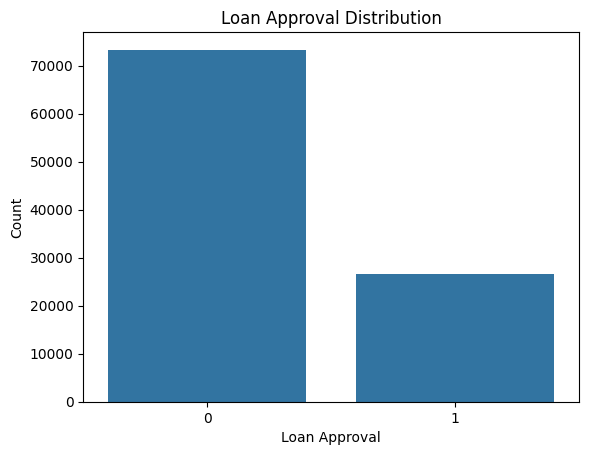

In [59]:
# Plot the distribution of loan approval
sns.countplot(x='Loan_Approval', data=df)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approval")
plt.ylabel("Count")
plt.show()

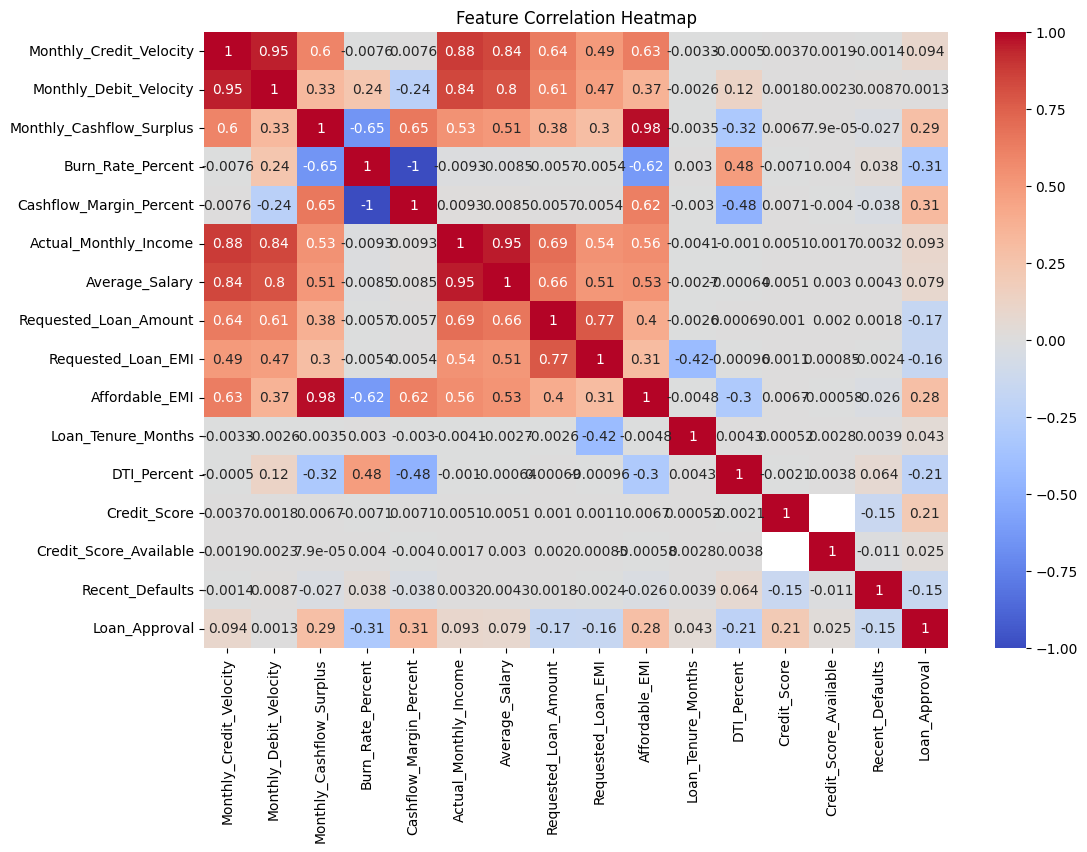

In [60]:
# Display the correlation heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

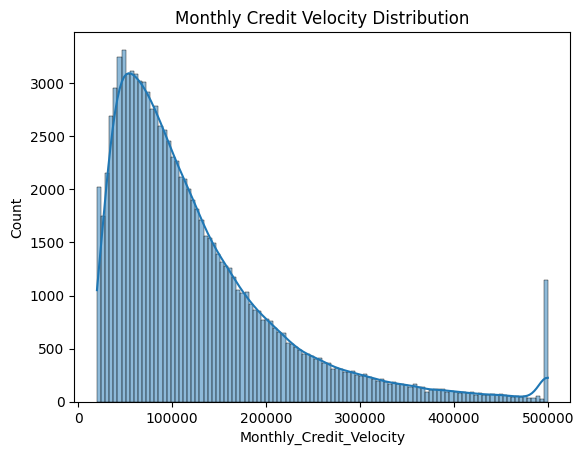

In [61]:
# Plot the distribution of monthly credit velocity

sns.histplot(df['Monthly_Credit_Velocity'], kde=True)
plt.title("Monthly Credit Velocity Distribution")
plt.show()

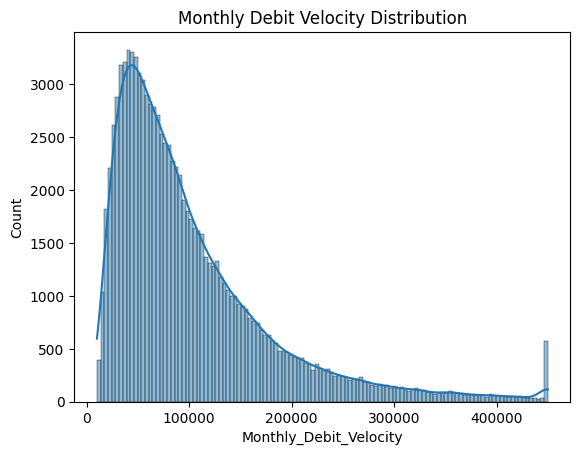

In [62]:
# Plot the distribution of monthly debit velocity

sns.histplot(df['Monthly_Debit_Velocity'], kde=True)
plt.title("Monthly Debit Velocity Distribution")
plt.show()

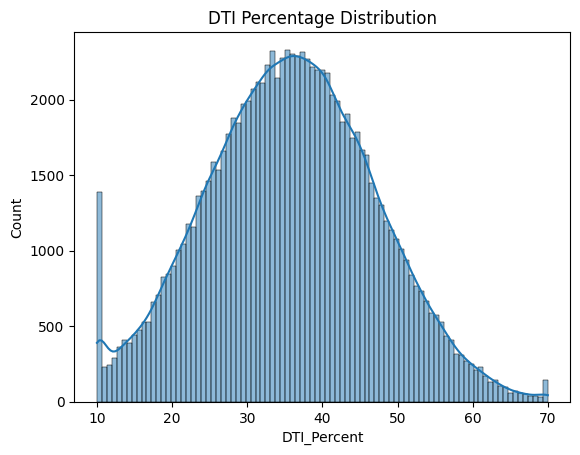

In [63]:
# Plot the distribution of DTI percentage

sns.histplot(df['DTI_Percent'], kde=True)
plt.title("DTI Percentage Distribution")
plt.show()

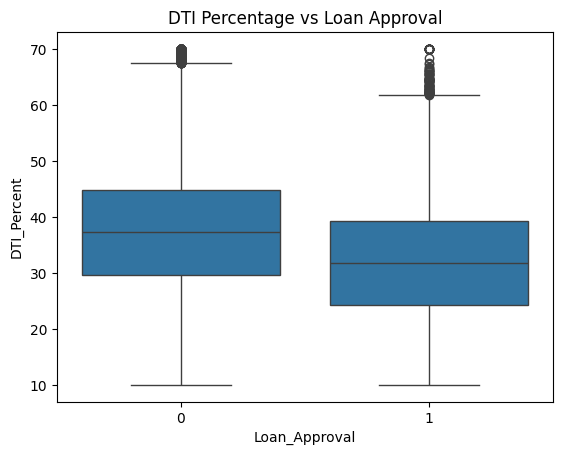

In [64]:
# Compare DTI percentage with loan approval

sns.boxplot(x='Loan_Approval',y='DTI_Percent',data=df)
plt.title("DTI Percentage vs Loan Approval")
plt.show()

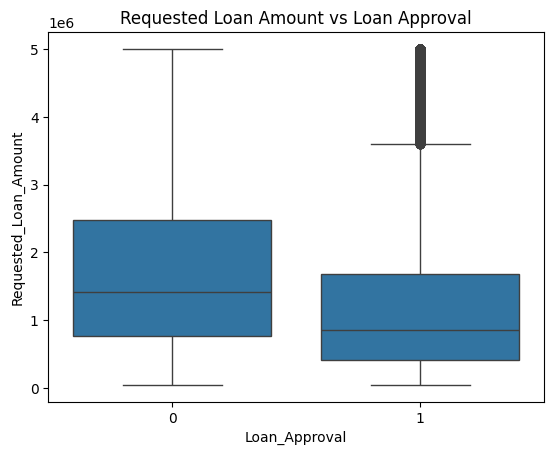

In [65]:
# Compare requested loan amount with loan approval

sns.boxplot(x='Loan_Approval',y='Requested_Loan_Amount',data=df)
plt.title("Requested Loan Amount vs Loan Approval")
plt.show()

In [66]:
df.head()

,Monthly_Credit_Velocity,Monthly_Debit_Velocity,Monthly_Cashflow_Surplus,Burn_Rate_Percent,Cashflow_Margin_Percent,Actual_Monthly_Income,Average_Salary,Salary_Stability,Requested_Loan_Amount,Requested_Loan_EMI,Affordable_EMI,Loan_Tenure_Months,DTI_Percent,Credit_Score,Credit_Score_Available,Credit_Repayment_History,Recent_Defaults,Loan_Approval
0,381935,335458,46477,87.83,12.17,134967,99712,Variable,3599933,183377.93,20285.28,24,10.00,696.0,1,Average,0,0
1,58255,59590,-1335,102.29,-2.29,22822,22936,Stable,344785,15854.45,0.00,24,41.76,679.0,1,Good,0,1
2,129862,104854,25008,80.74,19.26,56635,72828,Variable,1942830,76207.75,13690.07,36,36.49,788.0,1,Good,0,0
3,74164,47616,26548,64.20,35.80,52981,51837,Stable,977447,44939.60,12682.18,24,28.19,681.0,1,Good,0,1
4,500000,317826,182174,63.57,36.43,218363,223776,Stable,5000000,101887.94,78437.35,60,45.75,748.0,1,Good,0,1


In [67]:
# # Remove redundant and derived features to reduce feature overlap and maintain a simple, interpretable model

df=df.drop(columns=[
    'Burn_Rate_Percent',
    'Cashflow_Margin_Percent',
    'Actual_Monthly_Income',
    'Average_Salary',
    'Salary_Stability',
    'Affordable_EMI',
    'Credit_Score',
    'Credit_Score_Available',
    'Recent_Defaults'
])

In [68]:
df.head()

,Monthly_Credit_Velocity,Monthly_Debit_Velocity,Monthly_Cashflow_Surplus,Requested_Loan_Amount,Requested_Loan_EMI,Loan_Tenure_Months,DTI_Percent,Credit_Repayment_History,Loan_Approval
0,381935,335458,46477,3599933,183377.93,24,10.00,Average,0
1,58255,59590,-1335,344785,15854.45,24,41.76,Good,1
2,129862,104854,25008,1942830,76207.75,36,36.49,Good,0
3,74164,47616,26548,977447,44939.60,24,28.19,Good,1
4,500000,317826,182174,5000000,101887.94,60,45.75,Good,1


In [69]:
# Convert the Credit Repayment History categorical column into numerical dummy variables
# and drop the first category to avoid redundancy
df = pd.get_dummies(
    df,
    columns=['Credit_Repayment_History'],
    drop_first=True,
    dtype=int
)

In [70]:
df.head()

,Monthly_Credit_Velocity,Monthly_Debit_Velocity,Monthly_Cashflow_Surplus,Requested_Loan_Amount,Requested_Loan_EMI,Loan_Tenure_Months,DTI_Percent,Loan_Approval,Credit_Repayment_History_Good,Credit_Repayment_History_Poor
0,381935,335458,46477,3599933,183377.93,24,10.00,0,0,0
1,58255,59590,-1335,344785,15854.45,24,41.76,1,1,0
2,129862,104854,25008,1942830,76207.75,36,36.49,0,1,0
3,74164,47616,26548,977447,44939.60,24,28.19,1,1,0
4,500000,317826,182174,5000000,101887.94,60,45.75,1,1,0


In [71]:
# Check whether all features have been converted into numerical data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Monthly_Credit_Velocity        100000 non-null  int64  
 1   Monthly_Debit_Velocity         100000 non-null  int64  
 2   Monthly_Cashflow_Surplus       100000 non-null  int64  
 3   Requested_Loan_Amount          100000 non-null  int64  
 4   Requested_Loan_EMI             100000 non-null  float64
 5   Loan_Tenure_Months             100000 non-null  int64  
 6   DTI_Percent                    100000 non-null  float64
 7   Loan_Approval                  100000 non-null  int64  
 8   Credit_Repayment_History_Good  100000 non-null  int64  
 9   Credit_Repayment_History_Poor  100000 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 7.6 MB


In [72]:
# Separate the input features X from the target variable Y

X = df.drop(columns=['Loan_Approval'])
Y = df['Loan_Approval']

In [73]:
# Split the dataset into training and testing sets

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

**Evaluate the XGBoost model using different numbers of estimators (100 to 500) and tree depths ranging from 1 to 21 to identify the optimal hyperparameters**

In [74]:
#For n_estimators=100

accuracy=[]
f1=[]
recall=[]
precision=[]
depth=list(range(1,21))
for i in depth:
  xgb=XGBClassifier(n_estimators=100,max_depth=i,learning_rate=0.1,random_state=42,n_jobs=-1,verbosity=1)
  xgb.fit(X_train,Y_train)
  Y_pred=xgb.predict(X_test)
  accuracy.append(accuracy_score(Y_test,Y_pred))
  f1.append(f1_score(Y_test,Y_pred))
  recall.append(recall_score(Y_test,Y_pred))
  precision.append(precision_score(Y_test,Y_pred))

compare=pd.DataFrame({
    'Accuracy':accuracy,
    'Recall':recall,
    'F1':f1,
    'Precision':precision
},index=depth)
compare

,Accuracy,Recall,F1,Precision
1,0.78680,0.299888,0.429947,0.759207
2,0.80290,0.455054,0.553163,0.705202
3,0.80430,0.485267,0.570739,0.692758
4,0.80455,0.494778,0.575800,0.688554
5,0.80465,0.493473,0.575280,0.689601
6,0.80400,0.496643,0.576033,0.685633
7,0.80385,0.493846,0.574466,0.686544
8,0.80390,0.500373,0.577735,0.683393
9,0.80215,0.492913,0.571892,0.681010
10,0.80000,0.493473,0.569522,0.673282


## For n_estimators = 100, the best depth is 8.

In [75]:
#For n_estimators=200

accuracy=[]
f1=[]
recall=[]
precision=[]
depth=list(range(1,21))
for i in depth:
  xgb=XGBClassifier(n_estimators=200,max_depth=i,learning_rate=0.1,random_state=42,n_jobs=-1,verbosity=1)
  xgb.fit(X_train,Y_train)
  Y_pred=xgb.predict(X_test)
  accuracy.append(accuracy_score(Y_test,Y_pred))
  f1.append(f1_score(Y_test,Y_pred))
  recall.append(recall_score(Y_test,Y_pred))
  precision.append(precision_score(Y_test,Y_pred))

compare=pd.DataFrame({
    'Accuracy':accuracy,
    'Recall':recall,
    'F1':f1,
    'Precision':precision
},index=depth)
compare

,Accuracy,Recall,F1,Precision
1,0.79935,0.406751,0.520836,0.723863
2,0.80380,0.483961,0.569454,0.691631
3,0.80485,0.500000,0.578737,0.686908
4,0.80530,0.502238,0.580388,0.687340
5,0.80505,0.496643,0.577344,0.689361
6,0.80255,0.498322,0.575056,0.679725
7,0.80080,0.490116,0.568831,0.677669
8,0.80255,0.500746,0.576242,0.678544
9,0.79635,0.480977,0.558769,0.666581
10,0.79670,0.489183,0.563359,0.664051


## For n_estimators = 200, the best depth is 4

In [76]:
#For n_estimators=300

accuracy=[]
f1=[]
recall=[]
precision=[]
depth=list(range(1,21))
for i in depth:
  xgb=XGBClassifier(n_estimators=300,max_depth=i,learning_rate=0.1,random_state=42,n_jobs=-1,verbosity=1)
  xgb.fit(X_train,Y_train)
  Y_pred=xgb.predict(X_test)
  accuracy.append(accuracy_score(Y_test,Y_pred))
  f1.append(f1_score(Y_test,Y_pred))
  recall.append(recall_score(Y_test,Y_pred))
  precision.append(precision_score(Y_test,Y_pred))

compare=pd.DataFrame({
    'Accuracy':accuracy,
    'Recall':recall,
    'F1':f1,
    'Precision':precision
},index=depth)
compare

,Accuracy,Recall,F1,Precision
1,0.80165,0.435285,0.540591,0.713107
2,0.80485,0.495151,0.576359,0.689431
3,0.80480,0.502238,0.579763,0.685591
4,0.80590,0.504103,0.582041,0.688487
5,0.80420,0.497762,0.576832,0.685766
6,0.80120,0.498695,0.573574,0.674912
7,0.80040,0.491048,0.568805,0.675821
8,0.79865,0.495151,0.568705,0.667925
9,0.79470,0.484521,0.558590,0.659391
10,0.79555,0.490302,0.562533,0.659724


## For n_estimators = 300, the best depth is 4

In [77]:
#For n_estimators=400

accuracy=[]
f1=[]
recall=[]
precision=[]
depth=list(range(1,21))
for i in depth:
  xgb=XGBClassifier(n_estimators=400,max_depth=i,learning_rate=0.1,random_state=42,n_jobs=-1,verbosity=1)
  xgb.fit(X_train,Y_train)
  Y_pred=xgb.predict(X_test)
  accuracy.append(accuracy_score(Y_test,Y_pred))
  f1.append(f1_score(Y_test,Y_pred))
  recall.append(recall_score(Y_test,Y_pred))
  precision.append(precision_score(Y_test,Y_pred))

compare=pd.DataFrame({
    'Accuracy':accuracy,
    'Recall':recall,
    'F1':f1,
    'Precision':precision
},index=depth)
compare

,Accuracy,Recall,F1,Precision
1,0.80275,0.453003,0.551857,0.705899
2,0.80525,0.499814,0.579146,0.688415
3,0.80515,0.503543,0.580833,0.686150
4,0.80575,0.504103,0.581853,0.687961
5,0.80310,0.497762,0.575464,0.681911
6,0.80050,0.497389,0.572072,0.673145
7,0.79815,0.487878,0.564462,0.669567
8,0.79655,0.490489,0.563833,0.662969
9,0.79385,0.484334,0.557476,0.656637
10,0.79425,0.490302,0.560973,0.655448


## For n_estimators = 400, the best depth is 3

In [78]:
#For n_estimators=500

accuracy=[]
f1=[]
recall=[]
precision=[]
depth=list(range(1,21))
for i in depth:
  xgb=XGBClassifier(n_estimators=500,max_depth=i,learning_rate=0.1,random_state=42,n_jobs=-1,verbosity=1)
  xgb.fit(X_train,Y_train)
  Y_pred=xgb.predict(X_test)
  accuracy.append(accuracy_score(Y_test,Y_pred))
  f1.append(f1_score(Y_test,Y_pred))
  recall.append(recall_score(Y_test,Y_pred))
  precision.append(precision_score(Y_test,Y_pred))

compare=pd.DataFrame({
    'Accuracy':accuracy,
    'Recall':recall,
    'F1':f1,
    'Precision':precision
},index=depth)
compare

,Accuracy,Recall,F1,Precision
1,0.80265,0.460836,0.555968,0.700595
2,0.80535,0.501678,0.580179,0.687804
3,0.80450,0.502797,0.579660,0.684264
4,0.80575,0.503357,0.581493,0.688345
5,0.80205,0.495711,0.573154,0.679274
6,0.79915,0.495338,0.569407,0.669524
7,0.79705,0.488251,0.563314,0.665650
8,0.79510,0.489743,0.561711,0.658475
9,0.79230,0.483402,0.555151,0.651911
10,0.79115,0.488997,0.556629,0.645972


## For n_estimators = 500, the best depth is 4

## **Among all the tested n_estimators values, the best selection is n_estimators = 300 with max_depth = 4.**

In [118]:
## Final XGBoost Model


xgb=XGBClassifier(n_estimators=300,max_depth=4,learning_rate=0.1,random_state=42,n_jobs=-1,verbosity=1)
xgb.fit(X_train,Y_train)
Y_pred=xgb.predict(X_test)

Final_metrics = pd.DataFrame(
    {
        'XGBoost': [
            accuracy_score(Y_test, Y_pred),
            precision_score(Y_test, Y_pred),
            recall_score(Y_test, Y_pred),
            f1_score(Y_test, Y_pred)
        ]
    },
    index=['Accuracy', 'Precision', 'Recall', 'F1']
)
Final_metrics

,XGBoost
Accuracy,0.805900
Precision,0.688487
Recall,0.504103
F1,0.582041


In [119]:
# Generate the confusion matrix to evaluate the model's predictions

cm = confusion_matrix(Y_test, Y_pred)
print(cm)

[[13415  1223]
 [ 2659  2703]]


In [120]:
# Display the classification report for the model's predictions

print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87     14638
           1       0.69      0.50      0.58      5362

    accuracy                           0.81     20000
   macro avg       0.76      0.71      0.73     20000
weighted avg       0.80      0.81      0.80     20000



In [121]:
# Save the final XGBoost model as a pickle file

with open('Loan_prediction_model.pkl', 'wb') as f:
    p.dump(xgb, f)

In [122]:
with open('Loan_prediction_model.pkl', 'rb') as f:
    model = p.load(f)

In [123]:
df.sample(1)

,Monthly_Credit_Velocity,Monthly_Debit_Velocity,Monthly_Cashflow_Surplus,Requested_Loan_Amount,Requested_Loan_EMI,Loan_Tenure_Months,DTI_Percent,Loan_Approval,Credit_Repayment_History_Good,Credit_Repayment_History_Poor
55811,500000,333771,166229,5000000,245692.75,24,29.63,1,0,0


In [124]:
# Customer's financial and loan details used for prediction

customer_info = {
    "Monthly_Credit_Velocity": [150000],
    "Monthly_Debit_Velocity": [105000],
    "Monthly_Cashflow_Surplus": [45000],
    "Requested_Loan_Amount": [800000],
    "Requested_Loan_EMI": [15000],
    "Loan_Tenure_Months": [60],
    "DTI_Percent": [10],
    "Credit_Repayment_History_Good": [1],
    "Credit_Repayment_History_Poor": [0]
}

In [125]:
# Convert customer information into a DataFrame

customer = pd.DataFrame(customer_info)

In [126]:
# Predict loan approval for the customer

prediction = model.predict(customer)
prediction = prediction[0]

if prediction:
    print("Loan Approved.")
else:
    print("Loan Rejected.")

Loan Approved.


In [130]:
# Probability of getting the loan

print(f"Probability of Loan Rejection: {model.predict_proba(customer)[0][0] * 100:.3f}%")
print(f"Probability of Loan Approval: {model.predict_proba(customer)[0][1] * 100:.3f}%")

Probability of Loan Rejection: 14.430%
Probability of Loan Approval: 85.570%


# Conclusion

The developed XGBoost model is capable of predicting loan approval based on the customer's financial and repayment-related information. The model uses nine features, with credit repayment history being the most influential factor, followed by monthly cashflow surplus and requested loan amount. This indicates that repayment behavior and the customer's ability to maintain positive cashflow play an important role in the model's loan approval decisions. The model can therefore be used as a loan prediction and decision-support system to evaluate customer applications based on patterns learned from the dataset.